The content is from 'results_visualization_v2.ipynb' file of our RF-CRATE version 1 code base 

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
from func_utils import *

all_results_folder = "logs/"


## Ablation of Different Activation Functions

This experiments are conducted on the W3G6 dataset: no cross-domain testing:

```python
all_dataset:
  user_list: [1,2,3,4,5,6,7,8,9,10,11]   # the selected user list
  gesture_list: [0,6]       # the selected gesture from the SORTED_GES_LIST in tha widar3.py dataset file
  ges_from_same_folder: False  
  room_list: [1,3]     # the selected room list: 1, 2, 3
  select_rx: [1] # [1,2,3,4,5,6]
```

The input is the complex CSI

[0.8463983050847458, 0.8360699152542372, 0.8840042372881356, 0.9046610169491526]
[0.06679821337945038, 0.05992254786983909, 0.05227569094140527, 0.04741871418435994]


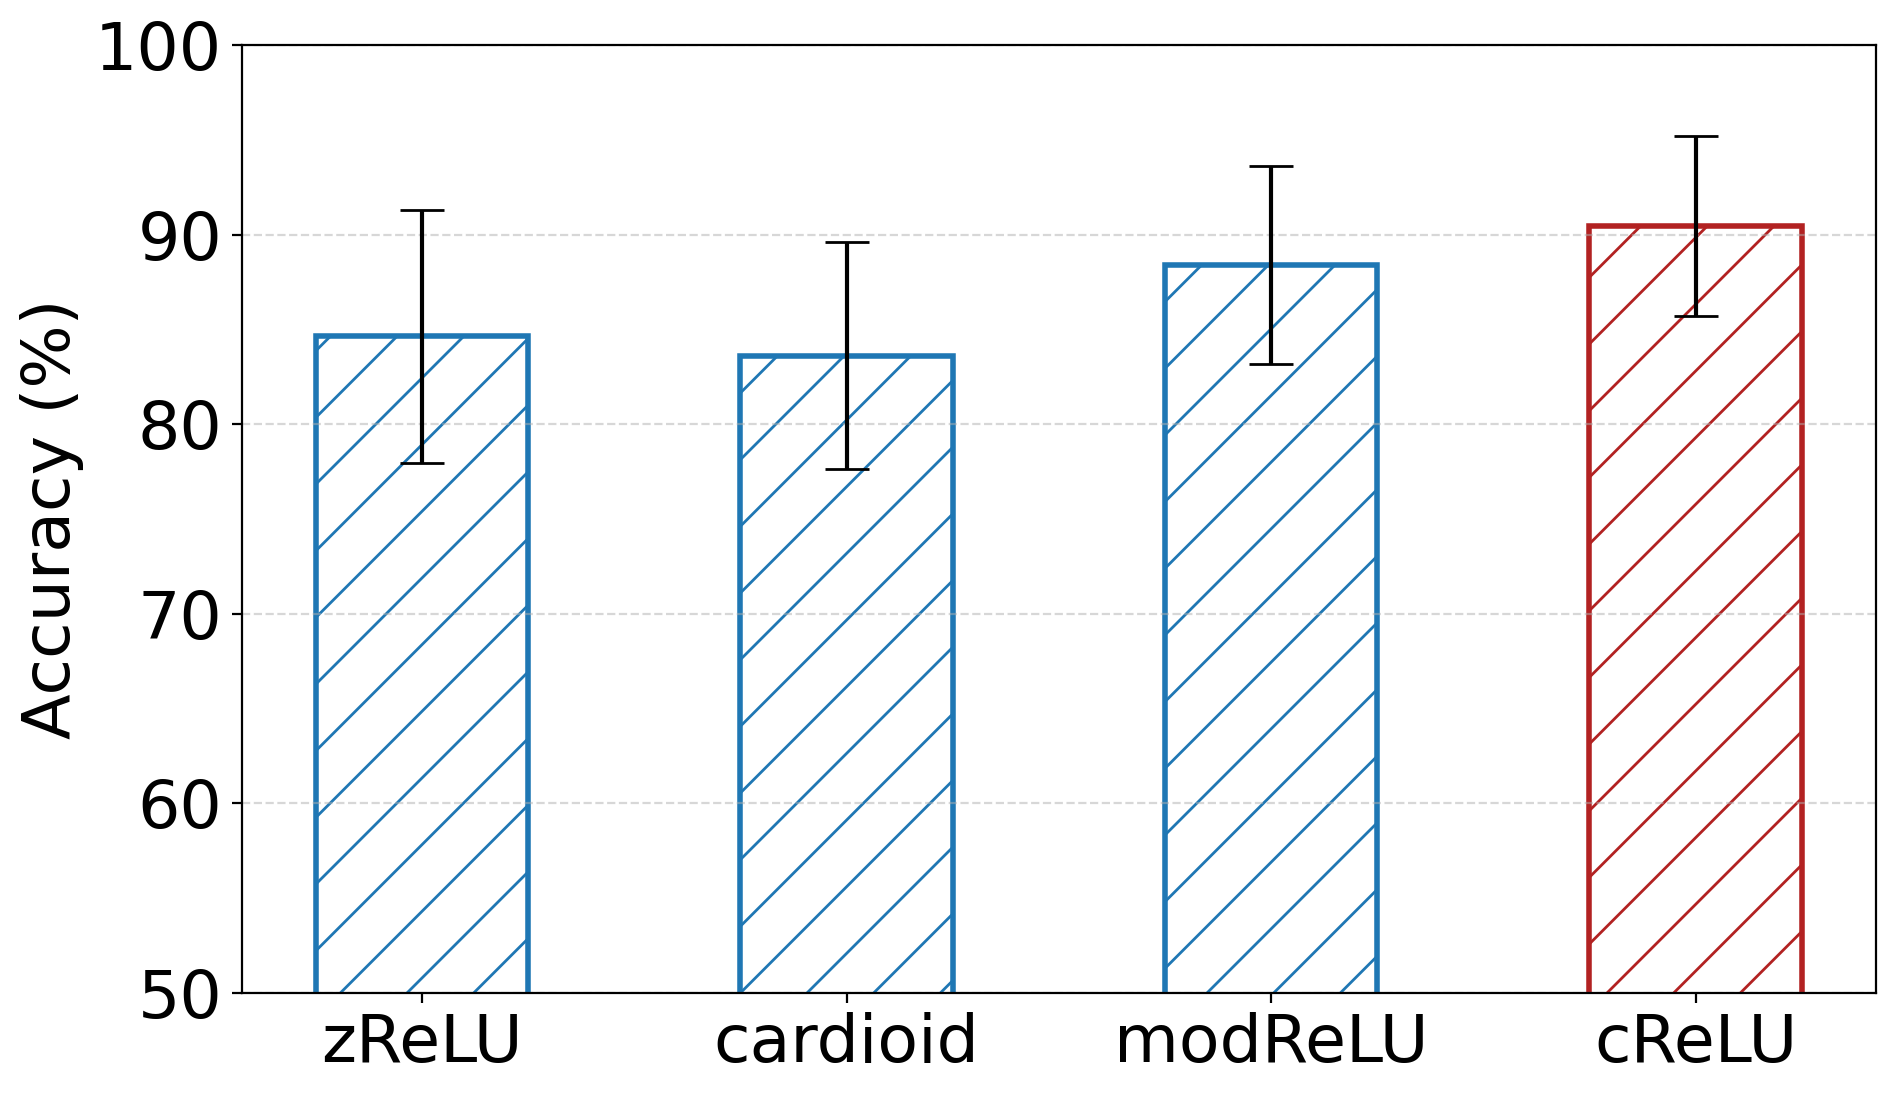

In [ ]:
results_files = [
    'widarDataset1_rfCRATEbase_zrelu_rf_crate_base_0822064253',
    'widarDataset1_rfCRATEbase_cardioid_rf_crate_base_0822085057',
    'widarDataset1_rfCRATEbase_moderelu_rf_crate_base_0822102017',
    'widarDataset1_rfCRATEbase_rf_crate_base_0822000626',

]

model_names = [ 
    'zReLU',
    'cardioid',
    'modReLU',
    'cReLU',
    ]


accuracy_list = []

for results_file in results_files:
    with open(all_results_folder + results_file + '.pkl', 'rb') as handle:
        results = pickle.load(handle)
        accuracy_list.append(results['metrics'])


mean_acc = []
std_acc = []

for acc in accuracy_list:
    # acc is a list of accuracies for each fold
    acc = np.array(acc)
    mean_acc.append(np.mean(acc))
    std_acc.append(np.std(acc))
print(mean_acc)
print(std_acc)


std_acc = np.array(std_acc)*100
mean_acc = np.array(mean_acc)*100

# Set the style parameters
plt.rcParams.update({'pdf.fonttype': 42})
plt.rcParams.update({'ps.fonttype': 42})
plt.rcParams.update({'font.size': 24})

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

bars = ax.bar(model_names[:-1], mean_acc[:-1], yerr=std_acc[:-1], width=0.5, capsize=8, 
              facecolor='none', hatch='/',edgecolor='tab:blue', linewidth=2,
              label='Other ReLu')

bars = ax.bar(model_names[-1:], mean_acc[-1:], yerr=std_acc[-1:], width=0.5, capsize=8, 
              facecolor='none', hatch='/',edgecolor='firebrick', linewidth=2,
              label='cReLU')

# Add value labels on top of each bar
# for bar in bars:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
#                 f'{height:.2f}%', ha='center', va='bottom', fontsize=20)

# Customize the plot
ax.set_ylabel('Accuracy (%)', fontsize=24)
# ax.set_yticklabels(ax.get_yticks(), fontsize=24)
# Add these lines to set the axes to black
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_color('black')

# Add a grid for better readability (optional)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(50,100)
# Adjust layout
fig.tight_layout()
# plt.xlabel('Datasets', fontsize=24)
# ax.tick_params(axis='both', which='major', color='black', length=6, width=1)
# ax.tick_params(axis='both', which='minor', color='black', length=3, width=1)
# Save the figure
# plt.savefig("figures/V2_ablation_relu.pdf", dpi=200, bbox_inches='tight')
plt.show()